# 01. Exploratory Data Analysis: CLINC150

Анализ датасета CLINC150 для задачи OOS-детекции.

**Prerequisite:** запустить `python scripts/prepare_data.py`

## 1. Setup

In [30]:
import sys
sys.path.insert(0, "../../..")
sys.path.insert(0, "..")

from src.data_utils import (
    load_split,
    load_fewshot,
    load_meta,
    get_intent_names
)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Data source
SOURCE = "deeppavlov"  # or "standard"

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2. Dataset Overview

In [31]:
# Load metadata
meta = load_meta(SOURCE)
print(f"Source: {SOURCE}")
print(f"OOS label in standard format: {meta.get('oos_label', -1)}")
print(f"Number of in-scope intents: {meta['n_intents']}")

Source: deeppavlov
OOS label in standard format: -1
Number of in-scope intents: 150


In [32]:
# Load all splits
train = load_split(SOURCE, "train")
val = load_split(SOURCE, "validation")
test = load_split(SOURCE, "test")

# Create overview table
def split_stats(data, name):
    labels = data["labels"]
    n_oos = sum(1 for l in labels if l == -1)
    n_inscope = len(labels) - n_oos
    oos_pct = 100 * n_oos / len(labels)
    return {
        "Split": name,
        "In-scope": n_inscope,
        "OOS": n_oos,
        "Total": len(labels),
        "OOS%": f"{oos_pct:.1f}%"
    }

overview = pd.DataFrame([
    split_stats(train, "train"),
    split_stats(val, "validation"),
    split_stats(test, "test")
])
print("\nDataset Overview:")
display(overview)


Dataset Overview:


,Split,In-scope,OOS,Total,OOS%
0,train,15000,200,15200,1.3%
1,validation,3000,100,3100,3.2%
2,test,4500,1000,5500,18.2%


In [33]:
print("\nNote: OOS% in test (~18%) represents a realistic guardrail scenario.")


Note: OOS% in test (~18%) represents a realistic guardrail scenario.


## 3. Intent Distribution

In [34]:
# Count examples per intent in train (excluding OOS)
train_inscope_labels = [l for l in train["labels"] if l != -1]
intent_counts = Counter(train_inscope_labels)

print(f"Number of unique intents in train: {len(intent_counts)}")
print(f"Examples per intent: min={min(intent_counts.values())}, "
      f"max={max(intent_counts.values())}, "
      f"mean={np.mean(list(intent_counts.values())):.1f}")

Number of unique intents in train: 150
Examples per intent: min=100, max=100, mean=100.0


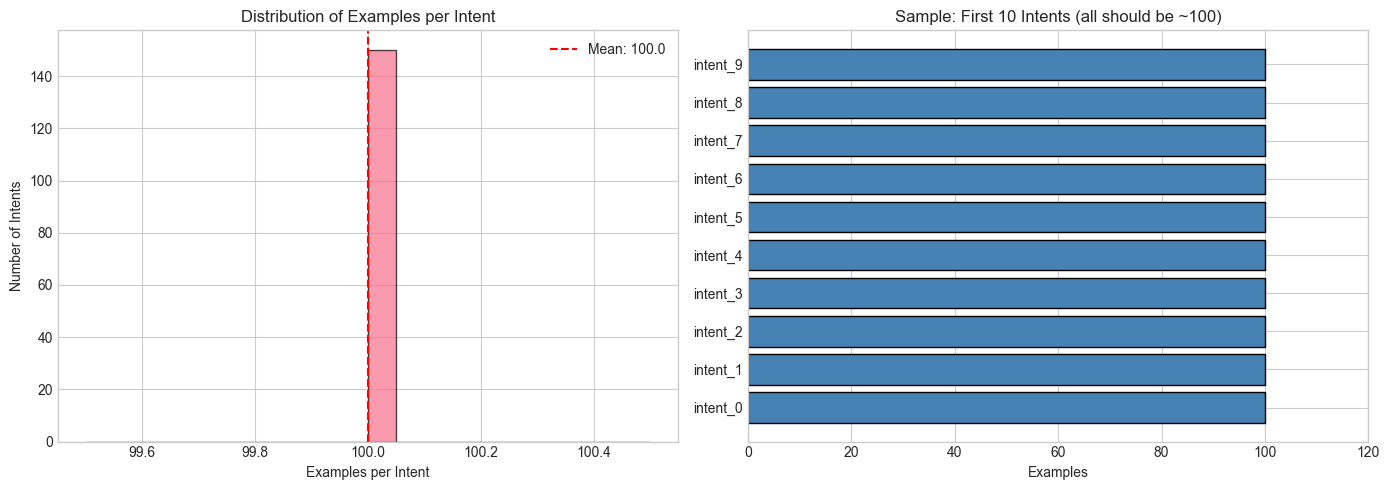


Dataset is BALANCED: range = 0
This is expected for CLINC150 — exactly 100 examples per intent.


In [35]:
# Visualize intent distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = list(intent_counts.values())

# Left: Histogram (will show single bar for balanced dataset)
axes[0].hist(counts, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
axes[0].set_xlabel('Examples per Intent')
axes[0].set_ylabel('Number of Intents')
axes[0].set_title('Distribution of Examples per Intent')
axes[0].legend()

# Right: Bar chart of top/bottom intents (or sample if all equal)
sorted_intents = sorted(intent_counts.items(), key=lambda x: x[1])
intent_names = get_intent_names(SOURCE)

# Show first 10 intents as sample
sample_intents = sorted_intents[:10]
names = [intent_names.get(i, f"intent_{i}")[:20] for i, _ in sample_intents]
values = [c for _, c in sample_intents]

axes[1].barh(names, values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Examples')
axes[1].set_title('Sample: First 10 Intents (all should be ~100)')
axes[1].set_xlim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

is_balanced = max(counts) - min(counts) <= 10
print(f"\nDataset is {'BALANCED' if is_balanced else 'IMBALANCED'}: "
      f"range = {max(counts) - min(counts)}")
print(f"This is expected for CLINC150 — exactly 100 examples per intent.")

## 4. OOS Analysis

In [36]:
# Sample OOS and in-scope examples from test
np.random.seed(42)

test_texts = test["texts"]
test_labels = test["labels"]

oos_indices = [i for i, l in enumerate(test_labels) if l == -1]
inscope_indices = [i for i, l in enumerate(test_labels) if l != -1]

sample_oos = np.random.choice(oos_indices, size=10, replace=False)
sample_inscope = np.random.choice(inscope_indices, size=10, replace=False)

print("10 Random OOS Examples (test):")
print("-" * 60)
for i in sample_oos:
    print(f"  {test_texts[i]}")

print("\n10 Random In-scope Examples (test):")
print("-" * 60)
intent_names = get_intent_names(SOURCE)
for i in sample_inscope:
    label = test_labels[i]
    intent_name = intent_names.get(label, "unknown")
    print(f"  [{intent_name}] {test_texts[i]}")

10 Random OOS Examples (test):
------------------------------------------------------------
  can you colorize a black and white photo
  accept incoming phone call
  what do i put on my feet
  do a job search on monstercom for jobs in the tech field in arlington, va
  can you check how many miles i walked today when i was out get the info from my phone
  what's the best price on a gray xl ll bean men's parka
  find articles that can help me advance my position in my work field
  is the movie avatar culturally insensitive
  how do you relieve a hangover
  sell three calls of of nvda

10 Random In-scope Examples (test):
------------------------------------------------------------
  [intent_62] can you give me instructions on how to jump start my car, please
  [intent_27] what's the preparation time for this dish
  [intent_125] give me the tire pressure for the car
  [intent_139] where do i look to get a w2
  [intent_18] my card declined
  [intent_68] i need to know what the point of life

In [37]:
print("\nObservation: OOS examples are often semantically similar to in-scope,")
print("making them challenging to detect. This is the 'hard OOS' scenario.")


Observation: OOS examples are often semantically similar to in-scope,
making them challenging to detect. This is the 'hard OOS' scenario.


## 5. Utterance Length Distribution

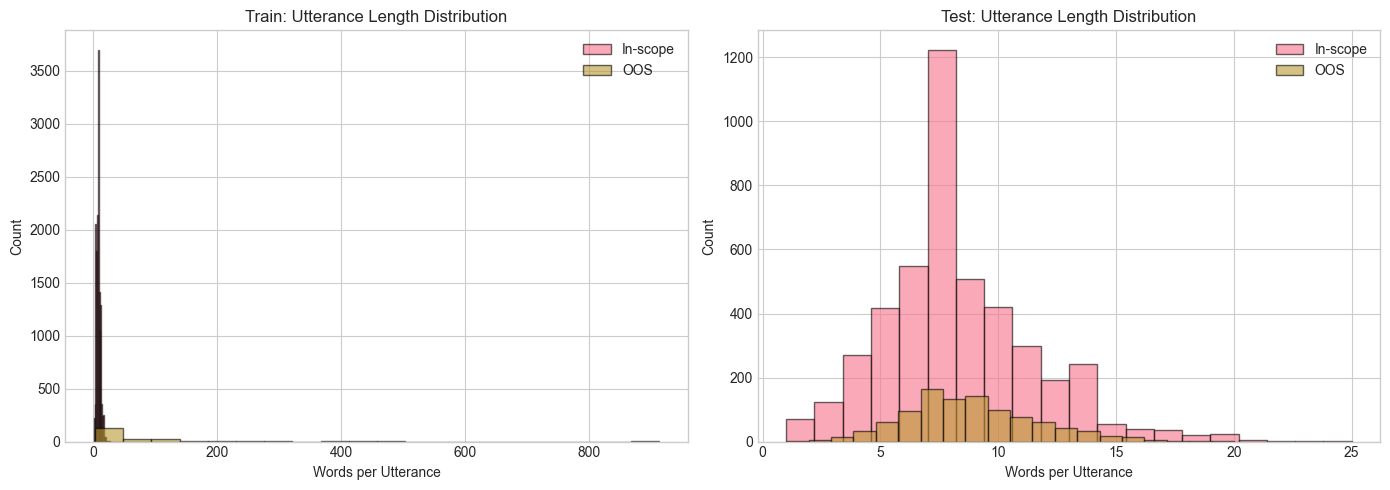


Train in-scope: mean=8.3 words
Train OOS: mean=68.8 words
Test in-scope: mean=8.2 words
Test OOS: mean=8.7 words


In [38]:
def word_count(text):
    return len(text.split())

# Train
train_oos_lengths = [word_count(t) for t, l in zip(train["texts"], train["labels"]) if l == -1]
train_inscope_lengths = [word_count(t) for t, l in zip(train["texts"], train["labels"]) if l != -1]

# Test
test_oos_lengths = [word_count(t) for t, l in zip(test["texts"], test["labels"]) if l == -1]
test_inscope_lengths = [word_count(t) for t, l in zip(test["texts"], test["labels"]) if l != -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].hist(train_inscope_lengths, bins=20, alpha=0.6, label='In-scope', edgecolor='black')
axes[0].hist(train_oos_lengths, bins=20, alpha=0.6, label='OOS', edgecolor='black')
axes[0].set_xlabel('Words per Utterance')
axes[0].set_ylabel('Count')
axes[0].set_title('Train: Utterance Length Distribution')
axes[0].legend()

# Test
axes[1].hist(test_inscope_lengths, bins=20, alpha=0.6, label='In-scope', edgecolor='black')
axes[1].hist(test_oos_lengths, bins=20, alpha=0.6, label='OOS', edgecolor='black')
axes[1].set_xlabel('Words per Utterance')
axes[1].set_ylabel('Count')
axes[1].set_title('Test: Utterance Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTrain in-scope: mean={np.mean(train_inscope_lengths):.1f} words")
print(f"Train OOS: mean={np.mean(train_oos_lengths):.1f} words")
print(f"Test in-scope: mean={np.mean(test_inscope_lengths):.1f} words")
print(f"Test OOS: mean={np.mean(test_oos_lengths):.1f} words")

## 6. Few-shot Splits

In [39]:
meta = load_meta(SOURCE)
fewshot_stats = []
for n in [10, 20, 50]:
    fs = load_fewshot(SOURCE, n, 42)
    n_oos = sum(1 for l in fs["labels"] if l == -1)
    n_inscope = len(fs["labels"]) - n_oos
    oos_pct = 100 * n_oos / len(fs["labels"])
    fewshot_stats.append({
        "n_shots": n,
        "In-scope": n_inscope,
        "OOS": n_oos,
        "Total": len(fs["labels"]),
        "OOS%": f"{oos_pct:.1f}%"
    })

fewshot_df = pd.DataFrame(fewshot_stats)
print("Few-shot Splits (seed=42):")
display(fewshot_df)

print(f"\nOOS ratio target: {meta['fewshot']['oos_ratio']} (= {int(meta['fewshot']['oos_ratio'] * 100)}%)")
print(f"Seeds used: {meta['fewshot']['seeds']}")

Few-shot Splits (seed=42):


,n_shots,In-scope,OOS,Total,OOS%
0,10,1500,150,1650,9.1%
1,20,3000,200,3200,6.2%
2,50,7500,200,7700,2.6%



OOS ratio target: 0.1 (= 10%)
Seeds used: [42, 123, 456]


## 7. Data Quality Checks

In [40]:
issues = []

# Check 1: Duplicates within train
train_texts_set = set(train["texts"])
n_duplicates = len(train["texts"]) - len(train_texts_set)
if n_duplicates > 0:
    issues.append(f"Found {n_duplicates} duplicate texts in train")
print(f"Duplicates in train: {n_duplicates}")

# Check 2: Train-test overlap
test_texts_set = set(test["texts"])
overlap = train_texts_set & test_texts_set
if len(overlap) > 0:
    issues.append(f"Found {len(overlap)} overlapping texts between train and test")
print(f"Train-test text overlap: {len(overlap)}")

# Show overlapping texts with their labels
if len(overlap) > 0:
    print("\nOverlapping texts (POTENTIAL DATA LEAKAGE):")
    for text in overlap:
        train_idx = train["texts"].index(text)
        test_idx = test["texts"].index(text)
        train_label = train["labels"][train_idx]
        test_label = test["labels"][test_idx]
        print(f"  '{text}'")
        print(f"    Train label: {train_label}, Test label: {test_label}")
        if train_label != test_label:
            print(f"    WARNING: Labels differ!")

# Check 3: OOS vs in-scope overlap (same text with different labels)
train_oos_texts = set(t for t, l in zip(train["texts"], train["labels"]) if l == -1)
train_inscope_texts = set(t for t, l in zip(train["texts"], train["labels"]) if l != -1)
oos_inscope_overlap = train_oos_texts & train_inscope_texts
if len(oos_inscope_overlap) > 0:
    issues.append(f"Found {len(oos_inscope_overlap)} texts labeled both OOS and in-scope")
print(f"\nOOS vs in-scope overlap: {len(oos_inscope_overlap)}")

# Check 4: All 150 intents present in train
unique_inscope_labels = set(l for l in train["labels"] if l != -1)
n_missing_intents = 150 - len(unique_inscope_labels)
if n_missing_intents > 0:
    issues.append(f"Missing {n_missing_intents} intents in train")
print(f"Unique in-scope intents in train: {len(unique_inscope_labels)} (expected: 150)")

# Check 5: OOS length anomalies
print(f"\nOOS length statistics:")
print(f"  Train OOS: mean={np.mean(train_oos_lengths):.1f}, std={np.std(train_oos_lengths):.1f}, max={max(train_oos_lengths)}")
print(f"  Test OOS:  mean={np.mean(test_oos_lengths):.1f}, std={np.std(test_oos_lengths):.1f}, max={max(test_oos_lengths)}")

if np.mean(train_oos_lengths) > 20:  # Anomaly threshold
    issues.append(f"Train OOS has anomalous length distribution (mean={np.mean(train_oos_lengths):.1f} words)")
    
    # Show examples of long OOS
    print(f"\nLong OOS examples in train (>50 words):")
    long_oos = [(t, word_count(t)) for t, l in zip(train["texts"], train["labels"]) 
                if l == -1 and word_count(t) > 50]
    for text, wc in sorted(long_oos, key=lambda x: -x[1])[:3]:
        print(f"  [{wc} words] '{text[:100]}...'")

print("\n" + "=" * 50)
if issues:
    print(f"ISSUES FOUND ({len(issues)}):")
    for issue in issues:
        print(f"  ⚠️  {issue}")
else:
    print("✓ All checks passed")

Duplicates in train: 0
Train-test text overlap: 2

Overlapping texts (POTENTIAL DATA LEAKAGE):
  'what's your designation'
    Train label: 143, Test label: 137
  'where did you grow up'
    Train label: 52, Test label: 145

OOS vs in-scope overlap: 0
Unique in-scope intents in train: 150 (expected: 150)

OOS length statistics:
  Train OOS: mean=68.8, std=119.1, max=913
  Test OOS:  mean=8.7, std=2.9, max=20

Long OOS examples in train (>50 words):
  [913 words] 'In order to not write a hateful review, I had to bring myself to the realization that this place is ...'
  [877 words] 'The side of sauteed Spinach was incredibly salty otherwise the color was wonderful and it smelled gr...'
  [502 words] 'I went to Sole on the weekend and found that it was so crowded and noisy I thought I would wait till...'

ISSUES FOUND (2):
  ⚠️  Found 2 overlapping texts between train and test
  ⚠️  Train OOS has anomalous length distribution (mean=68.8 words)


## 8. Сравнение источников: standard vs deeppavlov

In [41]:
# Load both sources for comparison
train_std = load_split("standard", "train")
train_dp = load_split("deeppavlov", "train")
test_std = load_split("standard", "test")
test_dp = load_split("deeppavlov", "test")

# Overview comparison
print("Dataset Size Comparison:")
print("=" * 60)
print(f"{'':20} {'standard':>15} {'deeppavlov':>15}")
print("-" * 60)
print(f"{'Train total':20} {len(train_std['texts']):>15,} {len(train_dp['texts']):>15,}")
print(f"{'Train OOS':20} {sum(1 for l in train_std['labels'] if l == -1):>15,} {sum(1 for l in train_dp['labels'] if l == -1):>15,}")
print(f"{'Test total':20} {len(test_std['texts']):>15,} {len(test_dp['texts']):>15,}")
print(f"{'Test OOS':20} {sum(1 for l in test_std['labels'] if l == -1):>15,} {sum(1 for l in test_dp['labels'] if l == -1):>15,}")
print()
print("Note: deeppavlov has 2x more OOS in train (200 vs 100)")

Dataset Size Comparison:
                            standard      deeppavlov
------------------------------------------------------------
Train total                   15,100          15,200
Train OOS                        100             200
Test total                     5,500           5,500
Test OOS                       1,000           1,000

Note: deeppavlov has 2x more OOS in train (200 vs 100)


OOS Utterance Length Comparison:
                            standard      deeppavlov
------------------------------------------------------------
Train OOS count                  100             200
Train OOS mean                   7.1            68.8
Train OOS median                 7.0            12.0
Train OOS std                    2.0           119.1
Train OOS max                     13             913
Test OOS mean                    8.7             8.7



/var/folders/4r/kcskh83x3rj2mwg0r3tgrbxm0000gn/T/ipykernel_71913/3632035699.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([std_train_oos_lengths, dp_train_oos_lengths],
/var/folders/4r/kcskh83x3rj2mwg0r3tgrbxm0000gn/T/ipykernel_71913/3632035699.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([std_test_oos_lengths, dp_test_oos_lengths],


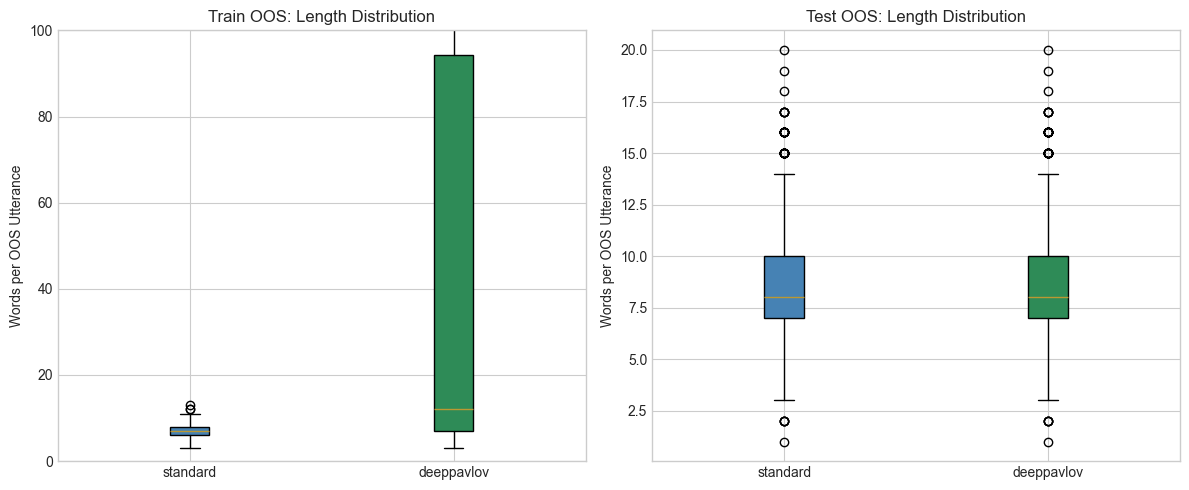


KEY FINDING: deeppavlov train OOS has anomalous length distribution!
  - standard train OOS: typical short utterances (mean=7.1, median=7 words)
  - deeppavlov train OOS: contains long texts (mean=68.8, median=12, max=913)
  - Test OOS is identical in both sources


In [49]:
# OOS length comparison between sources
std_train_oos_lengths = [word_count(t) for t, l in zip(train_std["texts"], train_std["labels"]) if l == -1]
dp_train_oos_lengths = [word_count(t) for t, l in zip(train_dp["texts"], train_dp["labels"]) if l == -1]
std_test_oos_lengths = [word_count(t) for t, l in zip(test_std["texts"], test_std["labels"]) if l == -1]
dp_test_oos_lengths = [word_count(t) for t, l in zip(test_dp["texts"], test_dp["labels"]) if l == -1]

print("OOS Utterance Length Comparison:")
print("=" * 60)
print(f"{'':20} {'standard':>15} {'deeppavlov':>15}")
print("-" * 60)
print(f"{'Train OOS count':20} {len(std_train_oos_lengths):>15} {len(dp_train_oos_lengths):>15}")
print(f"{'Train OOS mean':20} {np.mean(std_train_oos_lengths):>15.1f} {np.mean(dp_train_oos_lengths):>15.1f}")
print(f"{'Train OOS median':20} {np.median(std_train_oos_lengths):>15.1f} {np.median(dp_train_oos_lengths):>15.1f}")
print(f"{'Train OOS std':20} {np.std(std_train_oos_lengths):>15.1f} {np.std(dp_train_oos_lengths):>15.1f}")
print(f"{'Train OOS max':20} {max(std_train_oos_lengths):>15} {max(dp_train_oos_lengths):>15}")
print(f"{'Test OOS mean':20} {np.mean(std_test_oos_lengths):>15.1f} {np.mean(dp_test_oos_lengths):>15.1f}")
print()

# Box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train OOS box plot
bp1 = axes[0].boxplot([std_train_oos_lengths, dp_train_oos_lengths], 
                       labels=['standard', 'deeppavlov'], patch_artist=True)
bp1['boxes'][0].set_facecolor('steelblue')
bp1['boxes'][1].set_facecolor('seagreen')
axes[0].set_ylabel('Words per OOS Utterance')
axes[0].set_title('Train OOS: Length Distribution')
axes[0].set_ylim(0, 100)  # Truncate outliers for visibility

# Test OOS box plot  
bp2 = axes[1].boxplot([std_test_oos_lengths, dp_test_oos_lengths],
                       labels=['standard', 'deeppavlov'], patch_artist=True)
bp2['boxes'][0].set_facecolor('steelblue')
bp2['boxes'][1].set_facecolor('seagreen')
axes[1].set_ylabel('Words per OOS Utterance')
axes[1].set_title('Test OOS: Length Distribution')

plt.tight_layout()
plt.show()

print("\nKEY FINDING: deeppavlov train OOS has anomalous length distribution!")
print(f"  - standard train OOS: typical short utterances (mean={np.mean(std_train_oos_lengths):.1f}, median={np.median(std_train_oos_lengths):.0f} words)")
print(f"  - deeppavlov train OOS: contains long texts (mean={np.mean(dp_train_oos_lengths):.1f}, median={np.median(dp_train_oos_lengths):.0f}, max={max(dp_train_oos_lengths)})")
print(f"  - Test OOS is identical in both sources")

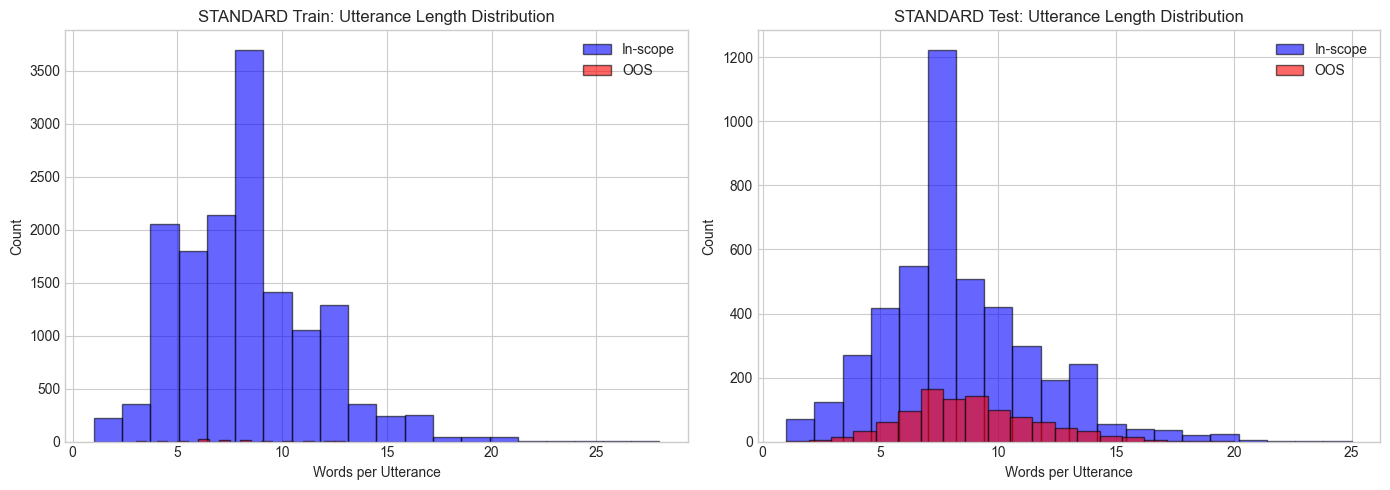

STANDARD - Train in-scope: mean=8.3 words
STANDARD - Train OOS: mean=7.1 words
STANDARD - Test in-scope: mean=8.2 words
STANDARD - Test OOS: mean=8.7 words


In [47]:
# Utterance Length Distribution for STANDARD source
std_train_inscope_lengths = [word_count(t) for t, l in zip(train_std["texts"], train_std["labels"]) if l != -1]
std_test_inscope_lengths = [word_count(t) for t, l in zip(test_std["texts"], test_std["labels"]) if l != -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].hist(std_train_inscope_lengths, bins=20, alpha=0.6, label='In-scope', 
             color='blue', edgecolor='black')
axes[0].hist(std_train_oos_lengths, bins=20, alpha=0.6, label='OOS', 
             color='red', edgecolor='black')
axes[0].set_xlabel('Words per Utterance')
axes[0].set_ylabel('Count')
axes[0].set_title('STANDARD Train: Utterance Length Distribution')
axes[0].legend()

# Test
axes[1].hist(std_test_inscope_lengths, bins=20, alpha=0.6, label='In-scope', 
             color='blue', edgecolor='black')
axes[1].hist(std_test_oos_lengths, bins=20, alpha=0.6, label='OOS', 
             color='red', edgecolor='black')
axes[1].set_xlabel('Words per Utterance')
axes[1].set_ylabel('Count')
axes[1].set_title('STANDARD Test: Utterance Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"STANDARD - Train in-scope: mean={np.mean(std_train_inscope_lengths):.1f} words")
print(f"STANDARD - Train OOS: mean={np.mean(std_train_oos_lengths):.1f} words")
print(f"STANDARD - Test in-scope: mean={np.mean(std_test_inscope_lengths):.1f} words")
print(f"STANDARD - Test OOS: mean={np.mean(std_test_oos_lengths):.1f} words")

In [48]:
# Show examples of anomalous long OOS from deeppavlov train
print("Examples of anomalously long OOS in deeppavlov train:")
print("=" * 60)
long_dp_oos = [(t, word_count(t)) for t, l in zip(train_dp["texts"], train_dp["labels"]) 
               if l == -1 and word_count(t) > 50]
for text, wc in sorted(long_dp_oos, key=lambda x: -x[1])[:5]:
    print(f"\n[{wc} words]")
    print(f"  '{text[:200]}{'...' if len(text) > 200 else ''}'")

print("\n" + "=" * 60)
print("These appear to be restaurant reviews, NOT typical assistant queries!")
print("This is a known issue with the DeepPavlov version of CLINC150.")
print()
print("Recommendation: use --source standard for cleaner OOS examples.")

Examples of anomalously long OOS in deeppavlov train:

[913 words]
  'In order to not write a hateful review, I had to bring myself to the realization that this place is supposed to be a 'healthy' buffet, not a 'good' buffet. \nI had never been here before, so I was del...'

[877 words]
  'The side of sauteed Spinach was incredibly salty otherwise the color was wonderful and it smelled great. The side of sauteed mushrooms looked really good, but they were way too peppery. I never season...'

[502 words]
  'I went to Sole on the weekend and found that it was so crowded and noisy I thought I would wait till later.  What better night to feed my paella hungrys than tonight when it rained cats and dogs - I w...'

[432 words]
  'Review for the Lounge/Club:\nEvery time I go to Vegas this is always one of my stops- primarily because of the view. I started going years ago before it was super hyped up and packed almost all the ti...'

[371 words]
  'I should have reviewed this place long ago but

In [45]:
# Train-test overlap comparison
print("Train-Test Overlap Comparison:")
print("=" * 60)

for source_name, train_data, test_data in [
    ("standard", train_std, test_std),
    ("deeppavlov", train_dp, test_dp)
]:
    train_set = set(train_data["texts"])
    test_set = set(test_data["texts"])
    overlap = train_set & test_set
    print(f"\n{source_name}:")
    print(f"  Overlapping texts: {len(overlap)}")
    
    if len(overlap) > 0:
        for text in overlap:
            train_idx = train_data["texts"].index(text)
            test_idx = test_data["texts"].index(text)
            train_label = train_data["labels"][train_idx]
            test_label = test_data["labels"][test_idx]
            label_match = "SAME" if train_label == test_label else "DIFFERENT"
            print(f"    '{text[:60]}...' -> labels: {label_match}")

Train-Test Overlap Comparison:

standard:
  Overlapping texts: 2
    'what's your designation...' -> labels: DIFFERENT
    'where did you grow up...' -> labels: DIFFERENT

deeppavlov:
  Overlapping texts: 2
    'what's your designation...' -> labels: DIFFERENT
    'where did you grow up...' -> labels: DIFFERENT


## 9. Summary

### Характеристики датасета

- 150 in-scope intent классов
- OOS base rate в test: ~18%
- Распределение интентов сбалансировано (~100 примеров на интент)
- OOS примеры семантически сложные (hard OOS)

### Сравнение источников

| Характеристика | standard | deeppavlov |
|----------------|----------|------------|
| Источник | github.com/clinc/oos-eval | HuggingFace DeepPavlov/clinc150 |
| Train total | 15,100 | 15,200 |
| Train OOS | 100 | 200 |
| Train OOS mean length | ~7 слов | ~69 слов |
| Train-test overlap | 2 текста (разные метки) | 2 текста (разные метки) |
| Проблемы качества | Overlap | Overlap + аномальные OOS (restaurant reviews) |

### Рекомендация

- **`--source standard`** — для более чистых экспериментов (нет аномальных OOS)
- **`--source deeppavlov`** — для сравнения с Table 3 (AutoIntent paper)